In [2]:
#import libraries
import os
import warnings
from pathlib import Path
import matplotlib
try:
    from IPython import get_ipython
    if get_ipython() is None or 'IPKernelApp' not in get_ipython().config:
        matplotlib.use('Agg')
except Exception:
    matplotlib.use('Agg')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor, StackingClassifier, StackingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, f1_score, mean_absolute_error, mean_squared_error, r2_score, silhouette_score, confusion_matrix, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from scipy.cluster.hierarchy import linkage, dendrogram

os.environ['LOKY_MAX_CPU_COUNT'] = '1'

PLOT_DIR = Path('generated_plots')
PLOT_DIR.mkdir(exist_ok=True)


In [3]:
PLOT_DIR = Path('generated_plots')
PLOT_DIR.mkdir(exist_ok=True)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
os.chdir('/content/drive/MyDrive/employability-ai-system')

In [6]:
# load dataset
data = pd.read_csv('data/raw/global_graduate_employability_index.csv')
data.head()

,Country,Region,University_Name,Degree_Level,Field_of_Study,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Top_Industry,Job_Role,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1–100),Remote_Work_Availability (%),Employer_Reputation_Score (1–100),Year
0,USA,North America,Harvard,Bachelor,Engineering,2017,79.3,85.6,66700,Manufacturing/Construction,Robotics Engineer,AutoCAD,Lean Six Sigma,MATLAB,69,8.8,66,2017
1,USA,North America,MIT,Bachelor,Engineering,2023,83.8,87.9,84500,Manufacturing/Construction,Civil Engineer,Lean Six Sigma,AutoCAD,MATLAB,71,65.4,63,2023
2,Israel,Middle East & Africa,Technion,Master,Healthcare & Medicine,2019,81.7,83.2,88300,Healthcare,Public Health Specialist,Clinical Research,Diagnostics,Patient Care,52,5.0,74,2019
3,India,Asia-Pacific,IIT Bombay,Master,Computer Science,2016,84.2,92.1,21000,Technology,AI Researcher,DevOps,Python,Cloud Computing,69,10.3,48,2016
4,South Africa,Middle East & Africa,University of Cape Town,PhD,Business & Finance,2023,83.6,86.3,48600,Finance/Consulting,Management Consultant,Financial Modeling,Data Analysis,Market Research,69,64.0,65,2023


Binary unemployability risk is defined as Employment_Rate_12_Months (%) <= 85.50.

Classification models ranked by ROC-AUC:
              Model  Accuracy  Precision  Recall     F1  ROC_AUC
Logistic Regression    0.7071     0.4551  0.8686 0.5972   0.8008
  Gradient Boosting    0.7429     0.4699  0.2229 0.3023   0.7924
      Random Forest    0.6814     0.4281  0.8171 0.5619   0.7823

Regression models ranked by R^2:
                      Model     R2   RMSE    MAE
Gradient Boosting Regressor 0.4517 4.6703 3.7183
    Random Forest Regressor 0.4262 4.7776 3.8056
           Ridge Regression 0.4018 4.8785 3.8384

Unsupervised risk segmentation using KMeans:
 Cluster  Count  Average_Employment_Rate  Risk_Rate  Silhouette_Score  Selected_K
       0   1830                  90.3275     0.2601            0.2181           2
       1   1670                  90.5033     0.2395            0.2181           2

Saved results to classification_model_results.csv, regression_model_results.csv, and risk_clu

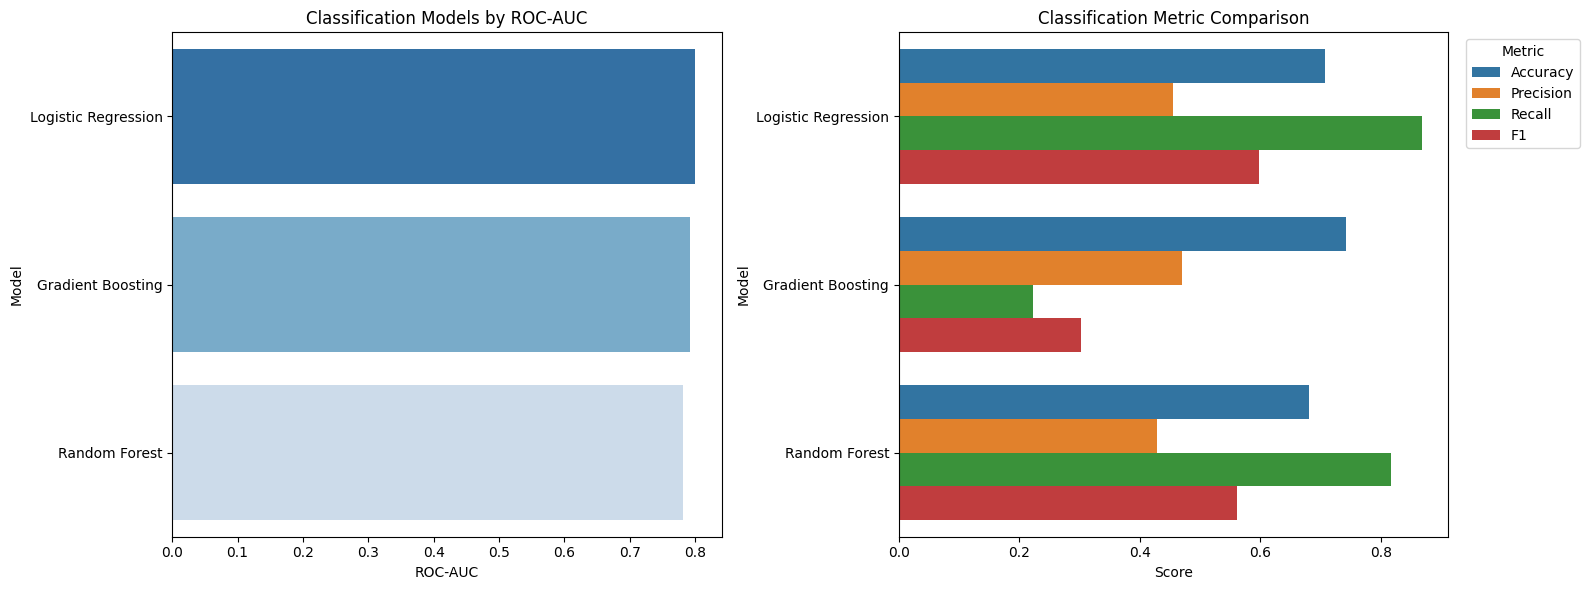

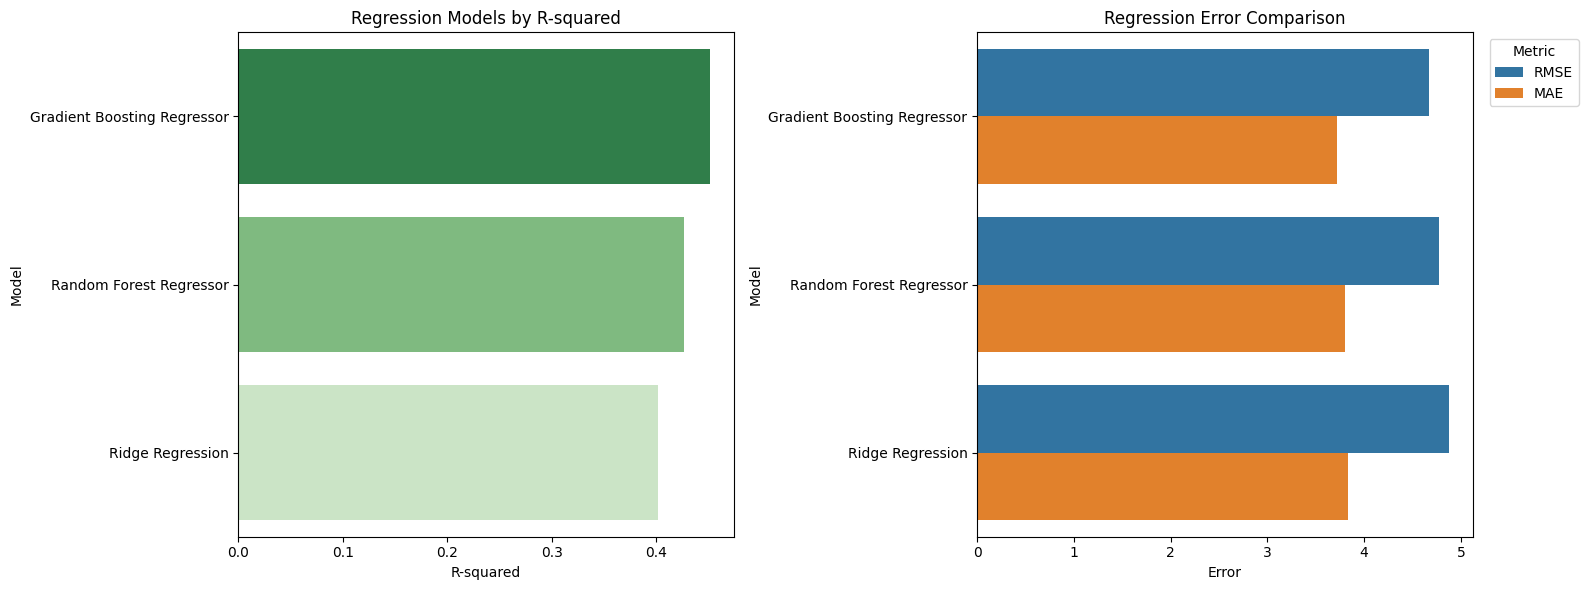

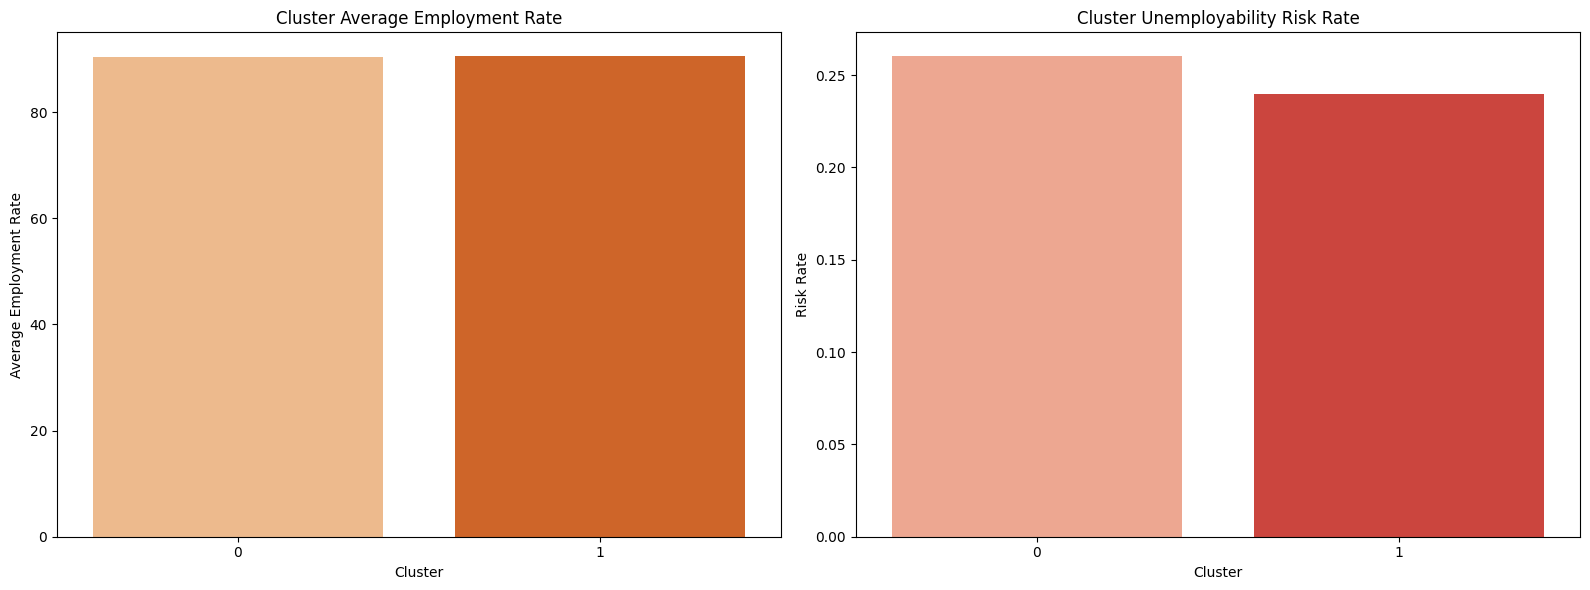

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.707143,0.455090,0.868571,0.597250,0.800827
1,Gradient Boosting,0.742857,0.469880,0.222857,0.302326,0.792414
2,Random Forest,0.681429,0.428144,0.817143,0.561886,0.782335


In [7]:
# Modeling section.
RANDOM_STATE = 42
SOURCE_FILE = 'data/raw/global_graduate_employability_index.csv'
CLASSIFICATION_RESULTS_FILE = 'classification_model_results.csv'
REGRESSION_RESULTS_FILE = 'regression_model_results.csv'
CLUSTER_RESULTS_FILE = 'risk_cluster_profile.csv'

def load_and_preserve_cleaning(path):
    model_df = pd.read_csv(path).copy()
    model_df.columns = model_df.columns.str.strip()
    model_df = model_df.drop(columns=['Year'], errors='ignore')

    for col in ['Employment_Rate_12_Months (%)', 'Average_Starting_Salary_USD']:
        q1 = model_df[col].quantile(0.25)
        q3 = model_df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        model_df[col] = model_df[col].clip(lower=lower_bound, upper=upper_bound)

    return model_df

def add_modeling_features(model_df):
    featured = model_df.copy()
    degree_map = {'Bachelor': 1, 'Master': 2, 'PhD': 3}
    featured['Degree_Level_Ordinal'] = featured['Degree_Level'].map(degree_map)
    featured['Graduation_Recency'] = featured['Graduation_Year'] - featured['Graduation_Year'].min()
    featured['Demand_x_Reputation'] = featured['Skill_Demand_Score (1–100)'] * featured['Employer_Reputation_Score (1–100)']
    featured['Demand_x_Remote'] = featured['Skill_Demand_Score (1–100)'] * featured['Remote_Work_Availability (%)']
    featured['Reputation_x_Remote'] = featured['Employer_Reputation_Score (1–100)'] * featured['Remote_Work_Availability (%)']
    featured['Skills_Profile'] = featured['Skill_1'].astype(str) + ' | ' + featured['Skill_2'].astype(str) + ' | ' + featured['Skill_3'].astype(str)
    return featured

def build_feature_table(model_df):
    target_regression = model_df['Employment_Rate_12_Months (%)'].copy()
    risk_cutoff = float(target_regression.quantile(0.25))
    target_classification = (target_regression <= risk_cutoff).astype(int)

    leakage_columns = [
        'Employment_Rate_12_Months (%)',
        'Employment_Rate_6_Months (%)',
        'Average_Starting_Salary_USD',
        'Top_Industry',
        'Job_Role',
        'University_Name'
    ]

    feature_table = model_df.drop(columns=leakage_columns, errors='ignore').copy()
    return feature_table, target_classification, target_regression, risk_cutoff

def build_preprocessor(X):
    categorical_cols = X.select_dtypes(include=['object', 'string', 'category', 'bool']).columns.tolist()
    numeric_cols = [col for col in X.columns if col not in categorical_cols]

    try:
        onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', onehot)
    ])

    return ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

def evaluate_classification_models(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=400, min_samples_leaf=3, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
    }

    rows = []
    for model_name, estimator in models.items():
        pipeline = Pipeline(steps=[('preprocessor', build_preprocessor(X_train)), ('model', estimator)])
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)
        scores = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, 'predict_proba') else pipeline.decision_function(X_test)

        rows.append({
            'Model': model_name,
            'Accuracy': accuracy_score(y_test, predictions),
            'Precision': precision_score(y_test, predictions, zero_division=0),
            'Recall': recall_score(y_test, predictions, zero_division=0),
            'F1': f1_score(y_test, predictions, zero_division=0),
            'ROC_AUC': roc_auc_score(y_test, scores)
        })

    return pd.DataFrame(rows).sort_values(by=['ROC_AUC', 'F1', 'Recall'], ascending=False).reset_index(drop=True)

def evaluate_regression_models(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

    models = {
        'Ridge Regression': Ridge(alpha=1.0),
        'Random Forest Regressor': RandomForestRegressor(n_estimators=400, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=1),
        'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=RANDOM_STATE)
    }

    rows = []
    for model_name, estimator in models.items():
        pipeline = Pipeline(steps=[('preprocessor', build_preprocessor(X_train)), ('model', estimator)])
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

        rows.append({
            'Model': model_name,
            'R2': r2_score(y_test, predictions),
            'RMSE': np.sqrt(mean_squared_error(y_test, predictions)),
            'MAE': mean_absolute_error(y_test, predictions)
        })

    return pd.DataFrame(rows).sort_values(by=['R2', 'RMSE'], ascending=[False, True]).reset_index(drop=True)

def evaluate_clustering_model(X, y_risk, y_rate):
    transformed = build_preprocessor(X).fit_transform(X)

    best_score = -np.inf
    best_labels = None
    best_k = None

    for n_clusters in range(2, 6):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=RANDOM_STATE)
            labels = kmeans.fit_predict(transformed)
            score = silhouette_score(transformed, labels)
        if score > best_score:
            best_score = score
            best_labels = labels
            best_k = n_clusters

    cluster_profile = pd.DataFrame({
        'Cluster': best_labels,
        'Employment_Rate_12_Months (%)': y_rate.values,
        'Unemployability_Risk': y_risk.values
    }).groupby('Cluster', as_index=False).agg(
        Count=('Cluster', 'size'),
        Average_Employment_Rate=('Employment_Rate_12_Months (%)', 'mean'),
        Risk_Rate=('Unemployability_Risk', 'mean')
    ).sort_values(by='Average_Employment_Rate').reset_index(drop=True)

    cluster_profile['Silhouette_Score'] = round(best_score, 4)
    cluster_profile['Selected_K'] = best_k
    return cluster_profile

def plot_classification_results(classification_results):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=classification_results, x='ROC_AUC', y='Model', hue='Model', palette='Blues_r', legend=False, ax=axes[0])
    axes[0].set_title('Classification Models by ROC-AUC')
    axes[0].set_xlabel('ROC-AUC')
    axes[0].set_ylabel('Model')

    classification_long = classification_results.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1'], var_name='Metric', value_name='Score')
    sns.barplot(data=classification_long, x='Score', y='Model', hue='Metric', ax=axes[1])
    axes[1].set_title('Classification Metric Comparison')
    axes[1].set_xlabel('Score')
    axes[1].set_ylabel('Model')
    axes[1].legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('classification_model_performance.png', bbox_inches='tight')
    plt.show()

def plot_regression_results(regression_results):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=regression_results, x='R2', y='Model', hue='Model', palette='Greens_r', legend=False, ax=axes[0])
    axes[0].set_title('Regression Models by R-squared')
    axes[0].set_xlabel('R-squared')
    axes[0].set_ylabel('Model')

    regression_long = regression_results.melt(id_vars='Model', value_vars=['RMSE', 'MAE'], var_name='Metric', value_name='Score')
    sns.barplot(data=regression_long, x='Score', y='Model', hue='Metric', ax=axes[1])
    axes[1].set_title('Regression Error Comparison')
    axes[1].set_xlabel('Error')
    axes[1].set_ylabel('Model')
    axes[1].legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('regression_model_performance.png', bbox_inches='tight')
    plt.show()

def plot_cluster_profile(cluster_profile):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=cluster_profile, x='Cluster', y='Average_Employment_Rate', hue='Cluster', palette='Oranges', legend=False, ax=axes[0])
    axes[0].set_title('Cluster Average Employment Rate')
    axes[0].set_xlabel('Cluster')
    axes[0].set_ylabel('Average Employment Rate')

    sns.barplot(data=cluster_profile, x='Cluster', y='Risk_Rate', hue='Cluster', palette='Reds', legend=False, ax=axes[1])
    axes[1].set_title('Cluster Unemployability Risk Rate')
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Risk Rate')

    plt.tight_layout()
    plt.savefig('cluster_profile.png', bbox_inches='tight')
    plt.show()

model_df = load_and_preserve_cleaning(SOURCE_FILE)
model_df = add_modeling_features(model_df)
X, y_classification, y_regression, risk_cutoff = build_feature_table(model_df)

classification_results = evaluate_classification_models(X, y_classification)
regression_results = evaluate_regression_models(X, y_regression)
cluster_profile = evaluate_clustering_model(X, y_classification, y_regression)

classification_results.to_csv(CLASSIFICATION_RESULTS_FILE, index=False)
regression_results.to_csv(REGRESSION_RESULTS_FILE, index=False)
cluster_profile.to_csv(CLUSTER_RESULTS_FILE, index=False)

print(f'Binary unemployability risk is defined as Employment_Rate_12_Months (%) <= {risk_cutoff:.2f}.')
print('\nClassification models ranked by ROC-AUC:')
print(classification_results.round(4).to_string(index=False))
print('\nRegression models ranked by R^2:')
print(regression_results.round(4).to_string(index=False))
print('\nUnsupervised risk segmentation using KMeans:')
print(cluster_profile.round(4).to_string(index=False))
print(f'\nSaved results to {CLASSIFICATION_RESULTS_FILE}, {REGRESSION_RESULTS_FILE}, and {CLUSTER_RESULTS_FILE}.')

plot_classification_results(classification_results)
plot_regression_results(regression_results)
plot_cluster_profile(cluster_profile)

classification_results


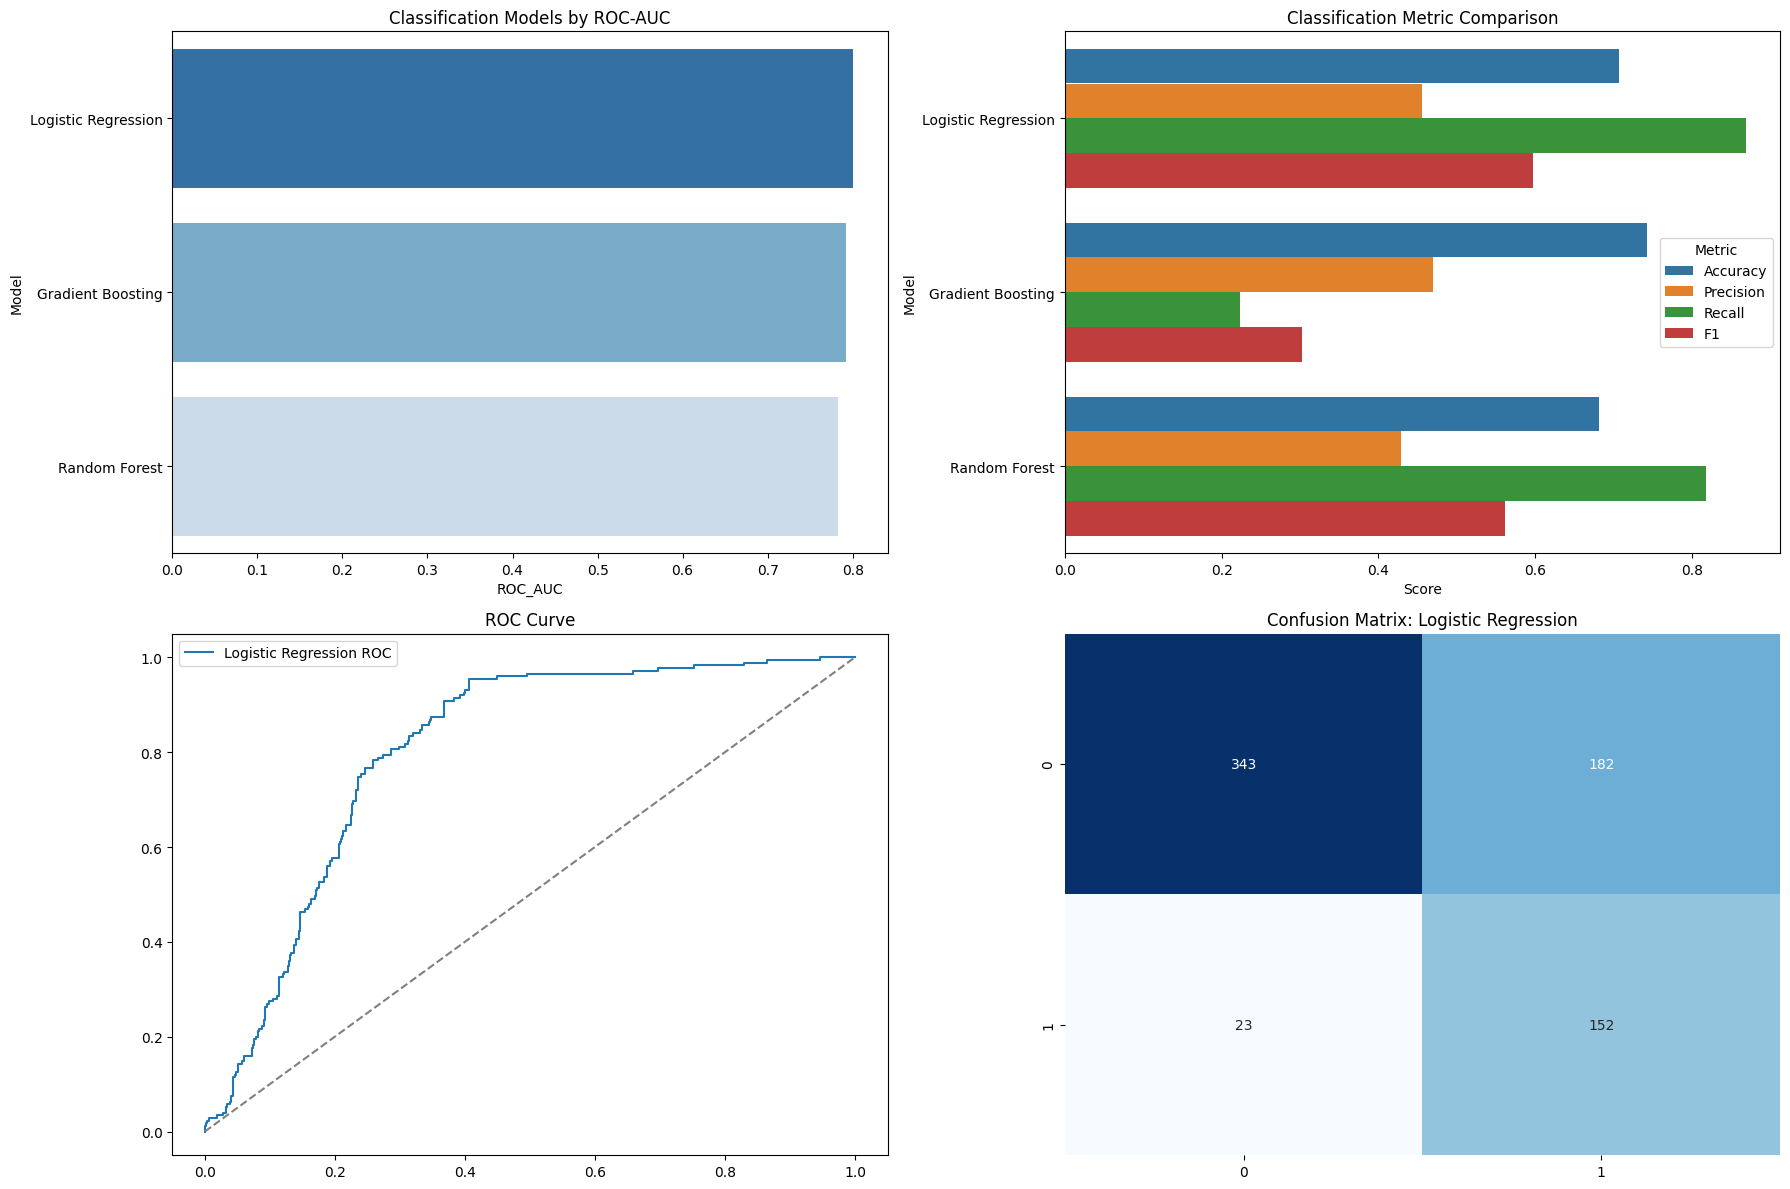

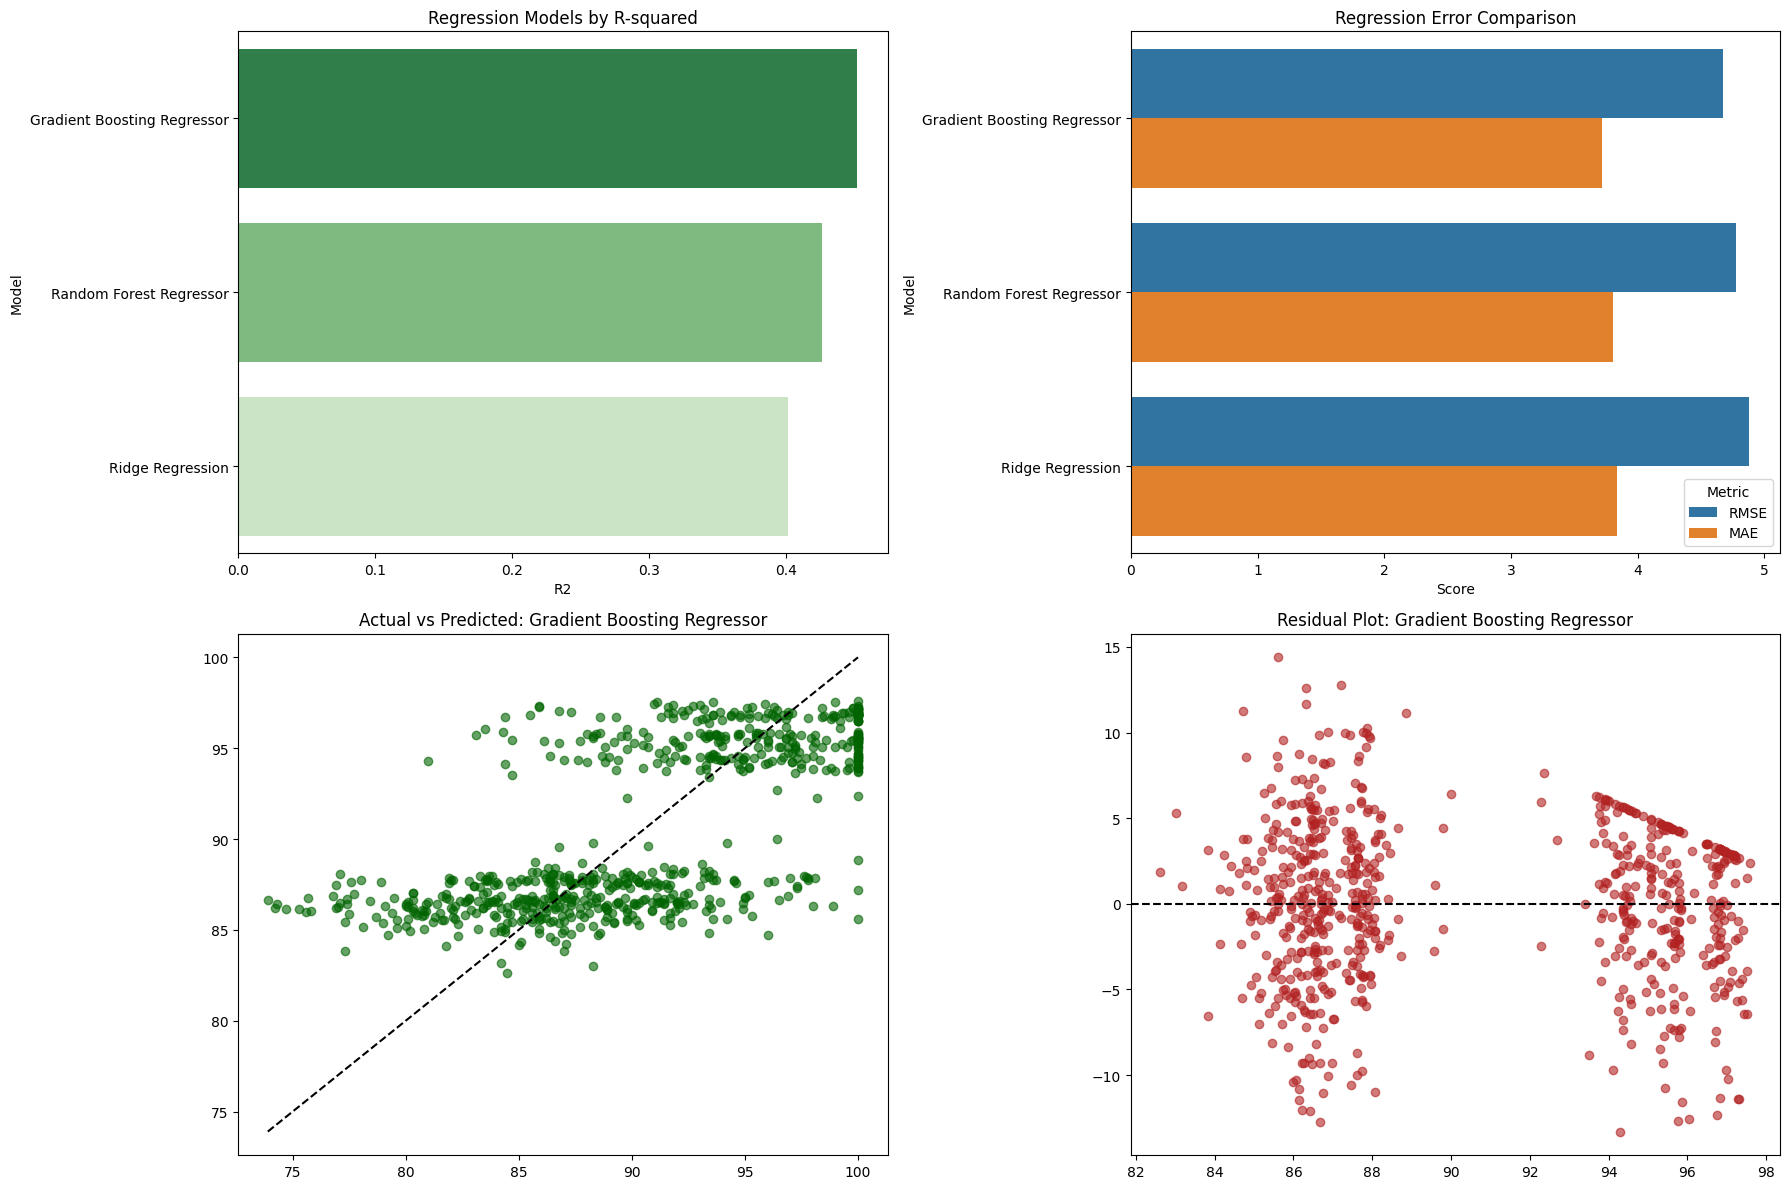

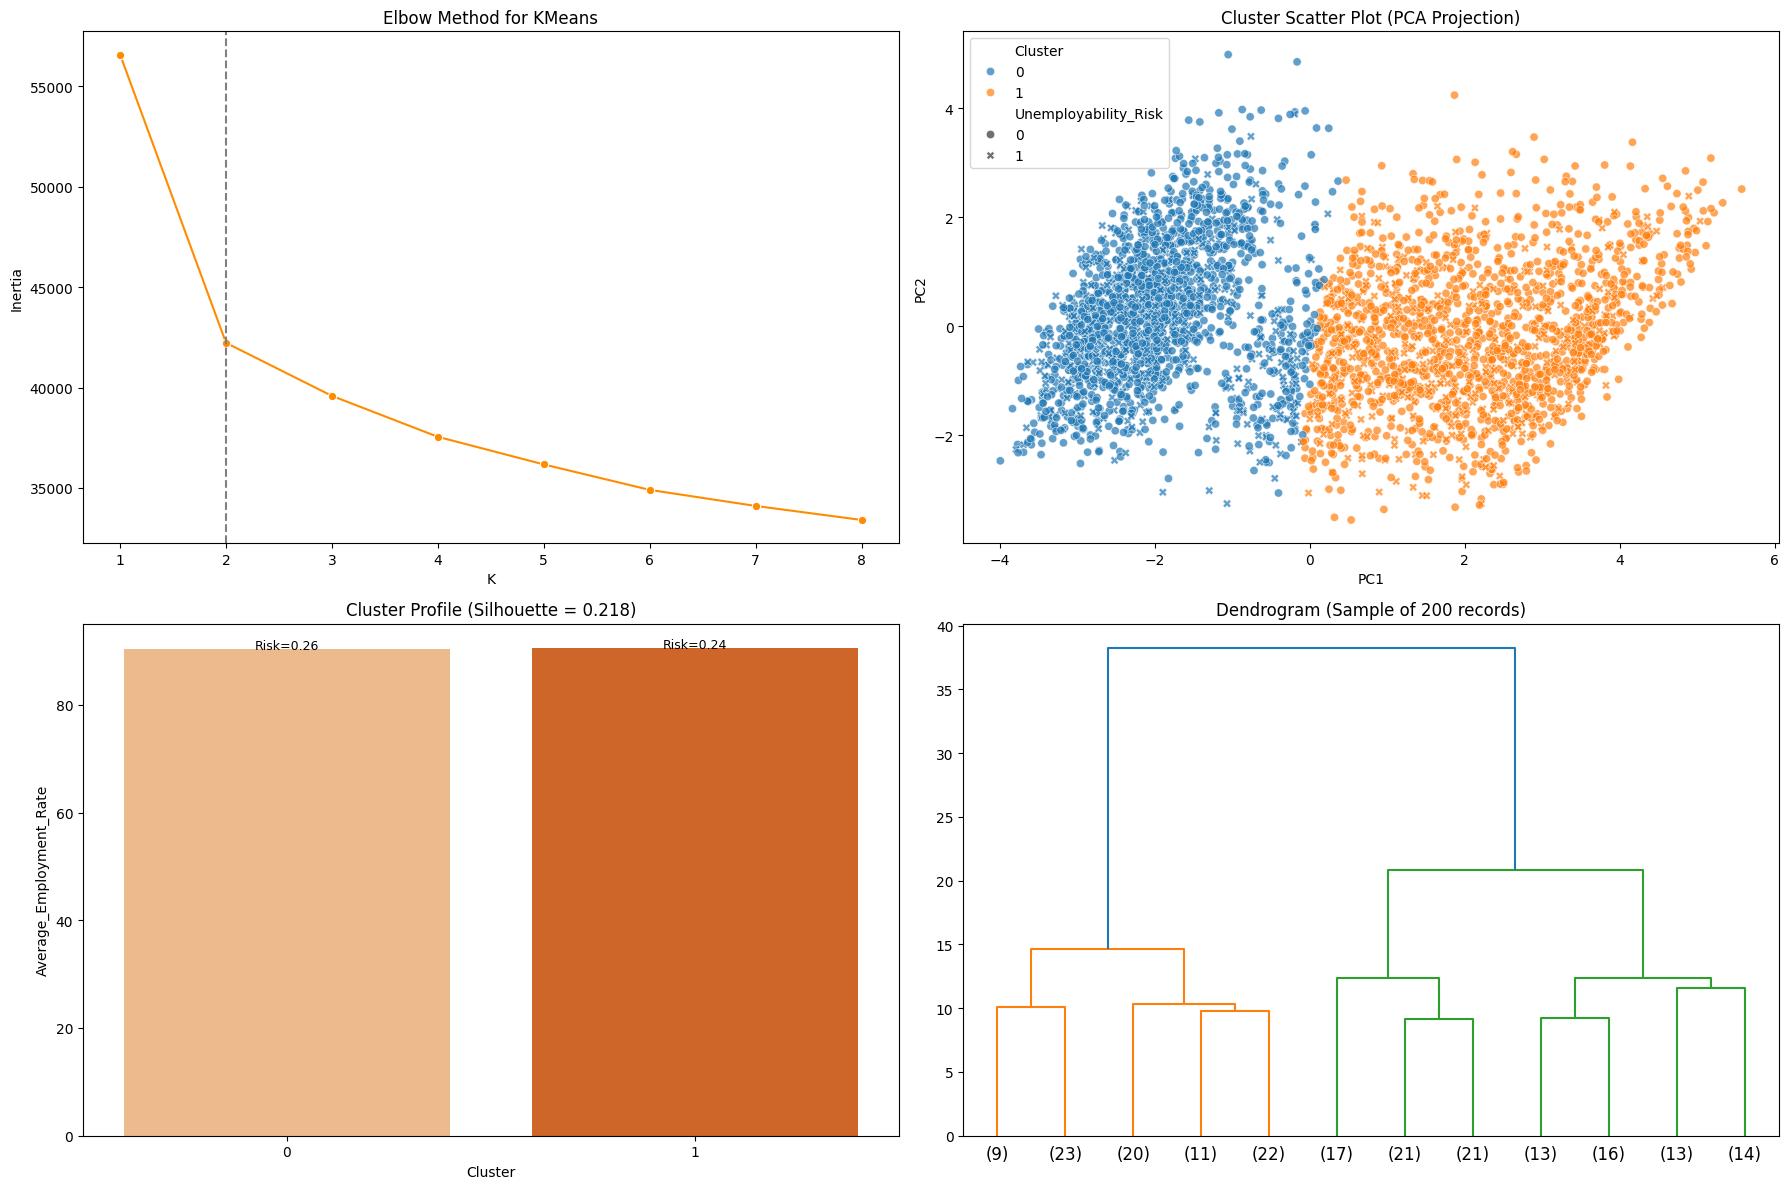

In [8]:
# Extra model visualizations for inline notebook display.
classification_model_map = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=400, min_samples_leaf=3, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}
regression_model_map = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=400, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=RANDOM_STATE)
}

best_classification_name = classification_results.iloc[0]['Model']
best_regression_name = regression_results.iloc[0]['Model']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_classification, test_size=0.2, random_state=RANDOM_STATE, stratify=y_classification)
best_cls_pipeline = Pipeline(steps=[('preprocessor', build_preprocessor(X_train_cls)), ('model', classification_model_map[best_classification_name])])
best_cls_pipeline.fit(X_train_cls, y_train_cls)
y_pred_cls = best_cls_pipeline.predict(X_test_cls)
y_score_cls = best_cls_pipeline.predict_proba(X_test_cls)[:, 1] if hasattr(best_cls_pipeline, 'predict_proba') else best_cls_pipeline.decision_function(X_test_cls)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size=0.2, random_state=RANDOM_STATE)
best_reg_pipeline = Pipeline(steps=[('preprocessor', build_preprocessor(X_train_reg)), ('model', regression_model_map[best_regression_name])])
best_reg_pipeline.fit(X_train_reg, y_train_reg)
y_pred_reg = best_reg_pipeline.predict(X_test_reg)
reg_residuals = y_test_reg - y_pred_reg

transformed = build_preprocessor(X).fit_transform(X)
elbow_rows = []
best_k = None
best_score = -np.inf
best_labels = None
for k in range(1, 9):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(transformed)
    elbow_rows.append({'K': k, 'Inertia': km.inertia_})
    if k > 1:
        sil = silhouette_score(transformed, labels)
        if sil > best_score:
            best_score = sil
            best_k = k
            best_labels = labels

cluster_coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(transformed)
cluster_scatter = pd.DataFrame({'PC1': cluster_coords[:, 0], 'PC2': cluster_coords[:, 1], 'Cluster': best_labels.astype(str), 'Unemployability_Risk': y_classification.values})
sample_size = min(200, transformed.shape[0])
sample_idx = np.random.default_rng(RANDOM_STATE).choice(np.arange(transformed.shape[0]), size=sample_size, replace=False)
linkage_matrix = linkage(transformed[sample_idx], method='ward')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(data=classification_results, x='ROC_AUC', y='Model', hue='Model', palette='Blues_r', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Classification Models by ROC-AUC')
classification_long = classification_results.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1'], var_name='Metric', value_name='Score')
sns.barplot(data=classification_long, x='Score', y='Model', hue='Metric', ax=axes[0, 1])
axes[0, 1].set_title('Classification Metric Comparison')
fpr, tpr, _ = roc_curve(y_test_cls, y_score_cls)
axes[1, 0].plot(fpr, tpr, label=f'{best_classification_name} ROC')
axes[1, 0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend()
sns.heatmap(confusion_matrix(y_test_cls, y_pred_cls), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1, 1])
axes[1, 1].set_title(f'Confusion Matrix: {best_classification_name}')
plt.tight_layout()
plt.savefig('classification_model_performance.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(data=regression_results, x='R2', y='Model', hue='Model', palette='Greens_r', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Regression Models by R-squared')
regression_long = regression_results.melt(id_vars='Model', value_vars=['RMSE', 'MAE'], var_name='Metric', value_name='Score')
sns.barplot(data=regression_long, x='Score', y='Model', hue='Metric', ax=axes[0, 1])
axes[0, 1].set_title('Regression Error Comparison')
axes[1, 0].scatter(y_test_reg, y_pred_reg, alpha=0.6, color='darkgreen')
axes[1, 0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], linestyle='--', color='black')
axes[1, 0].set_title(f'Actual vs Predicted: {best_regression_name}')
axes[1, 1].scatter(y_pred_reg, reg_residuals, alpha=0.6, color='firebrick')
axes[1, 1].axhline(0, linestyle='--', color='black')
axes[1, 1].set_title(f'Residual Plot: {best_regression_name}')
plt.tight_layout()
plt.savefig('regression_model_performance.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.lineplot(data=pd.DataFrame(elbow_rows), x='K', y='Inertia', marker='o', ax=axes[0, 0], color='darkorange')
axes[0, 0].axvline(best_k, linestyle='--', color='gray')
axes[0, 0].set_title('Elbow Method for KMeans')
sns.scatterplot(data=cluster_scatter, x='PC1', y='PC2', hue='Cluster', style='Unemployability_Risk', palette='tab10', alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title('Cluster Scatter Plot (PCA Projection)')
sns.barplot(data=cluster_profile, x='Cluster', y='Average_Employment_Rate', hue='Cluster', palette='Oranges', legend=False, ax=axes[1, 0])
axes[1, 0].set_title(f'Cluster Profile (Silhouette = {best_score:.3f})')
for idx, row in cluster_profile.iterrows():
    axes[1, 0].text(idx, row['Average_Employment_Rate'] + 0.1, f"Risk={row['Risk_Rate']:.2f}", ha='center', fontsize=9)
dendrogram(linkage_matrix, truncate_mode='lastp', p=12, ax=axes[1, 1], color_threshold=None)
axes[1, 1].set_title(f'Dendrogram (Sample of {sample_size} records)')
plt.tight_layout()
plt.savefig('cluster_analysis_dashboard.png', bbox_inches='tight')
plt.show()


Best tuned classification parameters:
{'model__C': 0.5, 'model__max_iter': 3000, 'model__solver': 'lbfgs'}

Best tuned regression parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 160}

Classification baseline vs tuned:
                    Model  Accuracy  Precision  Recall     F1  ROC_AUC     Type
      Logistic Regression    0.7071     0.4551  0.8686 0.5972   0.8008 Baseline
Tuned Logistic Regression    0.7057     0.4551  0.8971 0.6038   0.8013    Tuned

Regression baseline vs tuned:
                            Model     R2   RMSE    MAE     Type
      Gradient Boosting Regressor 0.4517 4.6703 3.7183 Baseline
Tuned Gradient Boosting Regressor 0.4552 4.6556 3.7074    Tuned


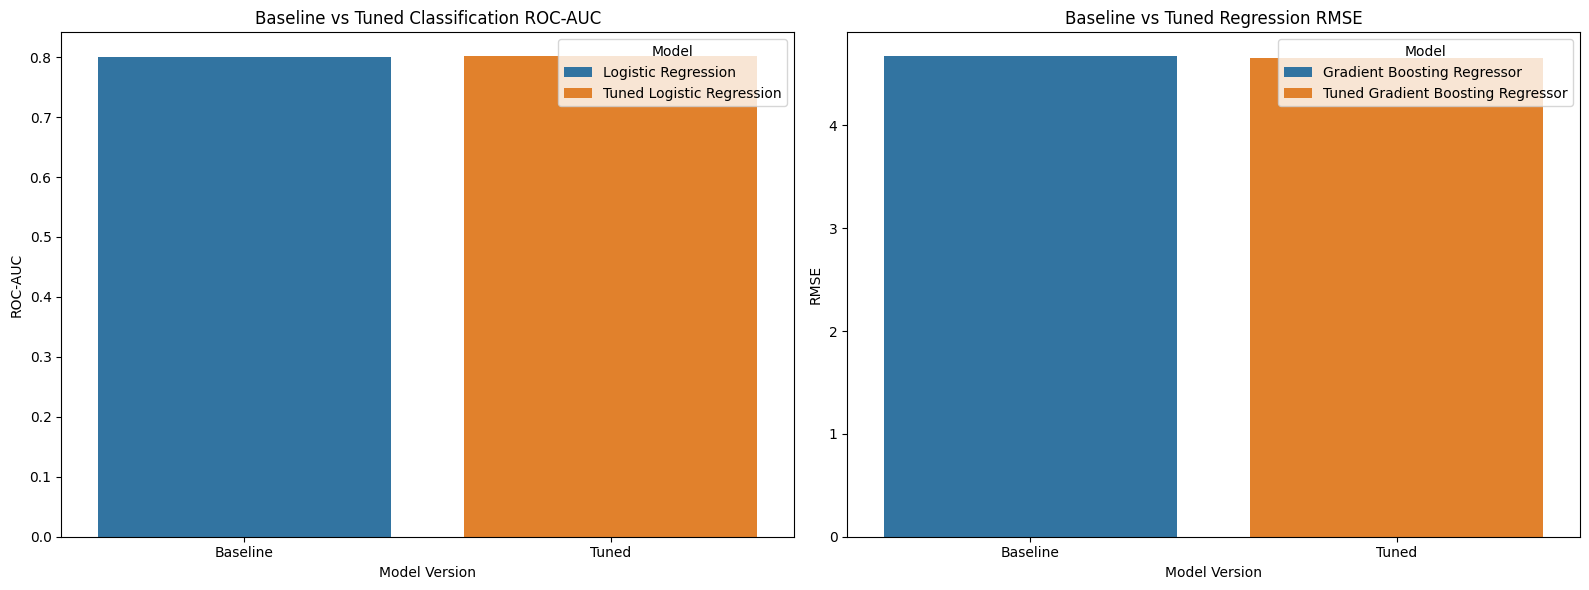

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Type
0,Logistic Regression,0.707143,0.455090,0.868571,0.597250,0.800827,Baseline
1,Tuned Logistic Regression,0.705714,0.455072,0.897143,0.603846,0.801328,Tuned


In [9]:
# Hyperparameter tuning for stronger predictive performance.
X_train_cls_tune, X_test_cls_tune, y_train_cls_tune, y_test_cls_tune = train_test_split(
    X, y_classification, test_size=0.2, random_state=RANDOM_STATE, stratify=y_classification
)
X_train_reg_tune, X_test_reg_tune, y_train_reg_tune, y_test_reg_tune = train_test_split(
    X, y_regression, test_size=0.2, random_state=RANDOM_STATE
)

best_baseline_classifier = classification_results.iloc[0]['Model']
best_baseline_regressor = regression_results.iloc[0]['Model']

classifier_search_space = {
    'Logistic Regression': (
        LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE),
        {'model__C': [0.5, 1.0, 5.0], 'model__solver': ['lbfgs'], 'model__max_iter': [3000]}
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),
        {'model__n_estimators': [300], 'model__max_depth': [None, 12], 'model__min_samples_leaf': [1, 3]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'model__n_estimators': [100, 160], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3]}
    )
}

regressor_search_space = {
    'Ridge Regression': (
        Ridge(),
        {'model__alpha': [0.1, 1.0, 5.0]}
    ),
    'Random Forest Regressor': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
        {'model__n_estimators': [300], 'model__max_depth': [None, 12], 'model__min_samples_leaf': [1, 3]}
    ),
    'Gradient Boosting Regressor': (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {'model__n_estimators': [100, 160], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3]}
    )
}

best_cls_estimator, best_cls_grid = classifier_search_space[best_baseline_classifier]
best_reg_estimator, best_reg_grid = regressor_search_space[best_baseline_regressor]

classification_search = GridSearchCV(
    Pipeline(steps=[('preprocessor', build_preprocessor(X_train_cls_tune)), ('model', best_cls_estimator)]),
    param_grid=best_cls_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,
    refit=True
)
classification_search.fit(X_train_cls_tune, y_train_cls_tune)
tuned_cls_pred = classification_search.predict(X_test_cls_tune)
tuned_cls_score = classification_search.predict_proba(X_test_cls_tune)[:, 1] if hasattr(classification_search, 'predict_proba') else classification_search.decision_function(X_test_cls_tune)

regression_search = GridSearchCV(
    Pipeline(steps=[('preprocessor', build_preprocessor(X_train_reg_tune)), ('model', best_reg_estimator)]),
    param_grid=best_reg_grid,
    scoring='neg_root_mean_squared_error',
    cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,
    refit=True
)
regression_search.fit(X_train_reg_tune, y_train_reg_tune)
tuned_reg_pred = regression_search.predict(X_test_reg_tune)

tuned_classification_results = pd.DataFrame([
    {
        'Model': f'Tuned {best_baseline_classifier}',
        'Accuracy': accuracy_score(y_test_cls_tune, tuned_cls_pred),
        'Precision': precision_score(y_test_cls_tune, tuned_cls_pred, zero_division=0),
        'Recall': recall_score(y_test_cls_tune, tuned_cls_pred, zero_division=0),
        'F1': f1_score(y_test_cls_tune, tuned_cls_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test_cls_tune, tuned_cls_score)
    }
])

tuned_regression_results = pd.DataFrame([
    {
        'Model': f'Tuned {best_baseline_regressor}',
        'R2': r2_score(y_test_reg_tune, tuned_reg_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_reg_tune, tuned_reg_pred)),
        'MAE': mean_absolute_error(y_test_reg_tune, tuned_reg_pred)
    }
])

classification_improvement = pd.concat([
    classification_results.head(1).assign(Type='Baseline'),
    tuned_classification_results.assign(Type='Tuned')
], ignore_index=True)
regression_improvement = pd.concat([
    regression_results.head(1).assign(Type='Baseline'),
    tuned_regression_results.assign(Type='Tuned')
], ignore_index=True)

print('Best tuned classification parameters:')
print(classification_search.best_params_)
print('\nBest tuned regression parameters:')
print(regression_search.best_params_)
print('\nClassification baseline vs tuned:')
print(classification_improvement.round(4).to_string(index=False))
print('\nRegression baseline vs tuned:')
print(regression_improvement.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=classification_improvement, x='Type', y='ROC_AUC', hue='Model', ax=axes[0])
axes[0].set_title('Baseline vs Tuned Classification ROC-AUC')
axes[0].set_xlabel('Model Version')
axes[0].set_ylabel('ROC-AUC')

sns.barplot(data=regression_improvement, x='Type', y='RMSE', hue='Model', ax=axes[1])
axes[1].set_title('Baseline vs Tuned Regression RMSE')
axes[1].set_xlabel('Model Version')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_tuning_comparison.png', bbox_inches='tight')
plt.show()

classification_improvement


## Tune ALL models

In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tuned_results = []

for model_name, (model, param_grid) in classifier_search_space.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', build_preprocessor(X_train_cls_tune)),
        ('model', model)
    ])

    search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    search.fit(X_train_cls_tune, y_train_cls_tune)

    y_pred = search.predict(X_test_cls_tune)
    y_prob = search.predict_proba(X_test_cls_tune)[:, 1]

    tuned_results.append({
        'Model': model_name,
        'Best_Params': search.best_params_,
        'ROC_AUC': roc_auc_score(y_test_cls_tune, y_prob),
        'Accuracy': accuracy_score(y_test_cls_tune, y_pred),
        'Precision': precision_score(y_test_cls_tune, y_pred, zero_division=0),
        'Recall': recall_score(y_test_cls_tune, y_pred, zero_division=0),
        'F1': f1_score(y_test_cls_tune, y_pred, zero_division=0)
    })

## Create comparison table

In [11]:
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df.sort_values(by='ROC_AUC', ascending=False)

print(tuned_results_df)

                 Model                                        Best_Params  \
0  Logistic Regression  {'model__C': 0.5, 'model__max_iter': 3000, 'mo...   
2    Gradient Boosting  {'model__learning_rate': 0.05, 'model__max_dep...   
1        Random Forest  {'model__max_depth': None, 'model__min_samples...   

    ROC_AUC  Accuracy  Precision    Recall        F1  
0  0.801328  0.705714   0.455072  0.897143  0.603846  
2  0.799347  0.745714   0.444444  0.068571  0.118812  
1  0.780941  0.681429   0.428144  0.817143  0.561886  


## Select best model

In [12]:
best_model_name = tuned_results_df.iloc[0]['Model']
print("Best model:", best_model_name)

Best model: Logistic Regression


## Extract best estimator

In [13]:
best_model = None

for model_name, (model, param_grid) in classifier_search_space.items():
    if model_name == best_model_name:
        best_model = model

## alternative

In [16]:
## Don’t just pick “best”—justify it
scoring='roc_auc'

In [17]:
# Adv
scoring = {
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'recall': 'recall'
}

In [23]:
best_models = {}
best_models[model_name] = search.best_estimator_
best_model_name = tuned_results_df.iloc[0]['Model']
best_model = best_models[best_model_name]

In [24]:
y_pred = best_model.predict(X_test_cls_tune)
y_prob = best_model.predict_proba(X_test_cls_tune)[:, 1]

In [27]:
predictions_df =X_test_cls_tune.copy()

predictions_df['Actual'] = y_test_cls_tune.values
predictions_df['Predicted'] = y_pred
predictions_df['Probability'] = y_prob

In [30]:
predictions_df

,Country,Region,Degree_Level,Field_of_Study,Graduation_Year,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1–100),Remote_Work_Availability (%),...,Degree_Level_Ordinal,Graduation_Recency,Demand_x_Reputation,Demand_x_Remote,Reputation_x_Remote,Skills_Profile,Actual,Predicted,Probability,Risk_Category
2061,Japan,Asia-Pacific,Master,Business & Finance,2015,Financial Modeling,Market Research,Excel,56,11.5,...,2,0,3752,644.0,770.5,Financial Modeling | Market Research | Excel,0,1,0.519180,Moderate
2174,China,Asia-Pacific,Master,Business & Finance,2019,Strategic Planning,Market Research,Excel,62,9.8,...,2,4,3906,607.6,617.4,Strategic Planning | Market Research | Excel,0,0,0.422397,Moderate
1529,Sweden,Europe,Bachelor,Engineering,2022,Project Management,Lean Six Sigma,AutoCAD,58,49.7,...,1,7,3654,2882.6,3131.1,Project Management | Lean Six Sigma | AutoCAD,0,1,0.541030,Moderate
2836,Israel,Middle East & Africa,Master,Computer Science,2019,DevOps,Cloud Computing,Java,79,14.4,...,2,4,5530,1137.6,1008.0,DevOps | Cloud Computing | Java,0,0,0.061408,Low Employability
128,Saudi Arabia,Middle East & Africa,Master,Natural Sciences,2017,Laboratory Skills,Statistical Analysis,Experimental Design,48,13.2,...,2,2,4032,633.6,1108.8,Laboratory Skills | Statistical Analysis | Exp...,0,0,0.376191,Low Employability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1612,South Africa,Middle East & Africa,Master,Data Science & AI,2022,R,Data Visualization,NLP,98,49.7,...,2,7,9114,4870.6,4622.1,R | Data Visualization | NLP,0,0,0.059323,Low Employability
1310,France,Europe,PhD,Natural Sciences,2016,Statistical Analysis,Scientific Writing,Experimental Design,45,7.7,...,3,1,2430,346.5,415.8,Statistical Analysis | Scientific Writing | Ex...,0,0,0.308253,Low Employability
2977,Mexico,Latin America,Master,Natural Sciences,2021,Experimental Design,Statistical Analysis,Scientific Writing,60,35.0,...,2,6,3960,2100.0,2310.0,Experimental Design | Statistical Analysis | S...,1,0,0.376191,Low Employability
2183,Sweden,Europe,Bachelor,Healthcare & Medicine,2021,Diagnostics,Clinical Research,Medical Coding,47,51.1,...,1,6,2256,2401.7,2452.8,Diagnostics | Clinical Research | Medical Coding,0,0,0.078521,Low Employability


In [28]:
predictions_df['Risk_Category'] = pd.cut(
    predictions_df['Probability'],
    bins=[0, 0.4, 0.7, 1],
    labels=['Low Employability', 'Moderate', 'High Employability']
)

In [31]:
predictions_df.head()

,Country,Region,Degree_Level,Field_of_Study,Graduation_Year,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1–100),Remote_Work_Availability (%),...,Degree_Level_Ordinal,Graduation_Recency,Demand_x_Reputation,Demand_x_Remote,Reputation_x_Remote,Skills_Profile,Actual,Predicted,Probability,Risk_Category
2061,Japan,Asia-Pacific,Master,Business & Finance,2015,Financial Modeling,Market Research,Excel,56,11.5,...,2,0,3752,644.0,770.5,Financial Modeling | Market Research | Excel,0,1,0.519180,Moderate
2174,China,Asia-Pacific,Master,Business & Finance,2019,Strategic Planning,Market Research,Excel,62,9.8,...,2,4,3906,607.6,617.4,Strategic Planning | Market Research | Excel,0,0,0.422397,Moderate
1529,Sweden,Europe,Bachelor,Engineering,2022,Project Management,Lean Six Sigma,AutoCAD,58,49.7,...,1,7,3654,2882.6,3131.1,Project Management | Lean Six Sigma | AutoCAD,0,1,0.541030,Moderate
2836,Israel,Middle East & Africa,Master,Computer Science,2019,DevOps,Cloud Computing,Java,79,14.4,...,2,4,5530,1137.6,1008.0,DevOps | Cloud Computing | Java,0,0,0.061408,Low Employability
128,Saudi Arabia,Middle East & Africa,Master,Natural Sciences,2017,Laboratory Skills,Statistical Analysis,Experimental Design,48,13.2,...,2,2,4032,633.6,1108.8,Laboratory Skills | Statistical Analysis | Exp...,0,0,0.376191,Low Employability


In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_cls_tune, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7457142857142857


In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_cls_tune, y_pred)
print(cm)

[[510  15]
 [163  12]]


In [34]:
from pathlib import Path

output_path = Path("data/processed")
output_path.mkdir(parents=True, exist_ok=True)

predictions_df.to_csv(output_path / "model_predictions.csv", index=False)